In [3]:
# src/ on the path - cwd is notebooks/
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import config

In [6]:
import joblib

from features import chip_features
from prepare import load_chips

rf = joblib.load(config.MODEL_PATH)

pred_full = np.zeros((config.AOI.height, config.AOI.width), dtype="uint8")

for c in tqdm(load_chips()):
    X = chip_features(c["img"])                  # (65536, 7)
    p = rf.predict(X).astype("uint8").reshape(config.CHIP, config.CHIP)
    pred_full[c["row"]:c["row"] + config.CHIP,
              c["col"]:c["col"] + config.CHIP] = p

# reuse the label profile, it already has the right CRS/transform/size
with rasterio.open(config.ALIGNED) as src:
    profile = src.profile

with rasterio.open(config.PRED, "w", **profile) as dst:
    dst.write(pred_full, 1)

print(f"predicted canopy fraction: {pred_full.mean():.3f}")

  0%|          | 0/1024 [00:00<?, ?it/s]

predicted canopy fraction: 0.325


In [12]:
import geopandas as gpd
from rasterstats import zonal_stats
from shapely.geometry import box

with rasterio.open(config.PRED) as src:
    aoi_poly = box(*src.bounds)
    raster_crs = src.crs

# zonal_stats does not reproject. mismatched CRS returns all None, no error.
nta = gpd.read_file(config.NTA_RAW).to_crs(raster_crs)
nta = nta[nta.intersects(aoi_poly)].copy()

for name, path in [("pred", config.PRED), ("ref", config.ALIGNED)]:
    stats = zonal_stats(nta, str(path), stats=["mean"], nodata=255)
    nta[f"canopy_{name}"] = [
        (s["mean"] * 100) if s["mean"] is not None else np.nan for s in stats
    ]

nta["error"] = nta["canopy_pred"] - nta["canopy_ref"]

# partly-clipped NTAs give misleading totals, flag rather than drop silently
nta["fully_inside"] = nta.within(aoi_poly)

nta.to_file(config.NTA_STATS, driver="GeoJSON")
nta[["canopy_pred", "canopy_ref", "error"]].describe()

,canopy_pred,canopy_ref,error
count,25.000000,25.000000,25.000000
mean,28.938097,23.509667,5.428430
std,18.770693,11.060831,9.817543
min,7.000000,4.451613,0.383834
25%,18.678231,17.128280,1.123546
50%,24.532807,21.077085,1.906351
75%,28.413843,26.507492,3.714050
max,82.121685,58.446085,38.113403


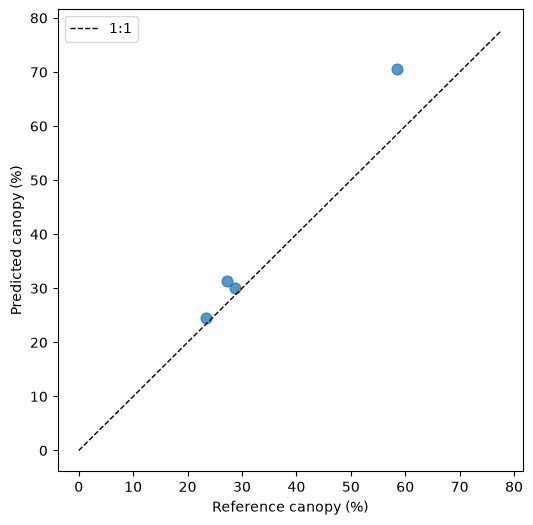

bias +4.7 pp, MAE 4.7 pp


In [13]:
full = nta[nta["fully_inside"]]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(full["canopy_ref"], full["canopy_pred"], s=60, alpha=0.75)

lim = [0, max(full["canopy_ref"].max(), full["canopy_pred"].max()) * 1.1]
ax.plot(lim, lim, "k--", lw=1, label="1:1")
ax.set_xlabel("Reference canopy (%)")
ax.set_ylabel("Predicted canopy (%)")
ax.legend()

plt.savefig(config.FIGURES / "04_nta_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"bias {full['error'].mean():+.1f} pp, MAE {full['error'].abs().mean():.1f} pp")

In [14]:
import folium

nta_web = gpd.read_file(config.NTA_STATS).to_crs(4326)
print(nta_web.columns.tolist())

[':id', ':version', ':created_at', ':updated_at', 'borocode', 'boroname', 'countyfips', 'nta2020', 'ntaname', 'ntaabbrev', 'ntatype', 'cdta2020', 'cdtaname', 'shape_leng', 'shape_area', 'canopy_pred', 'canopy_ref', 'error', 'fully_inside', 'geometry']


In [15]:
NAME_FIELD = "ntaname"

# folium serialises EVERY column to JSON, not just the ones referenced below.
# NYC's NTA file carries date columns that can't serialise, which raises
# "Object of type Timestamp is not JSON serializable". Keep only what the map
# needs.
nta_web = nta_web[[NAME_FIELD, "canopy_pred", "canopy_ref", "error", "geometry"]].copy()

centre = nta_web.geometry.union_all().centroid   # unary_union on geopandas < 1.0

# m = folium.Map(location=[centre.y, centre.x], zoom_start=13, tiles="CartoDB positron")
m = folium.Map(location=[centre.y, centre.x], zoom_start=13, tiles="OpenStreetMap")

folium.Choropleth(
    geo_data=nta_web,
    data=nta_web,
    columns=[NAME_FIELD, "canopy_pred"],
    key_on=f"feature.properties.{NAME_FIELD}",
    fill_color="YlGn",
    fill_opacity=0.7,
    line_weight=1,
    legend_name="Predicted tree canopy (%)",
).add_to(m)

# invisible layer just to carry tooltips - Choropleth has no hover
folium.GeoJson(
    nta_web,
    style_function=lambda f: {"fillOpacity": 0, "weight": 0},
    tooltip=folium.GeoJsonTooltip(
        fields=[NAME_FIELD, "canopy_pred", "canopy_ref", "error"],
        aliases=["Neighbourhood", "Predicted %", "Reference %", "Error (pp)"],
        localize=True,
    ),
).add_to(m)

m.save(config.DOCS / "index.html")
# m

The interactive map doesn't render in GitHub's static notebook viewer. Static version below; live version at [Canopy Interactive Map](https://geobrec.github.io/nyc-canopy-segmentaion/).

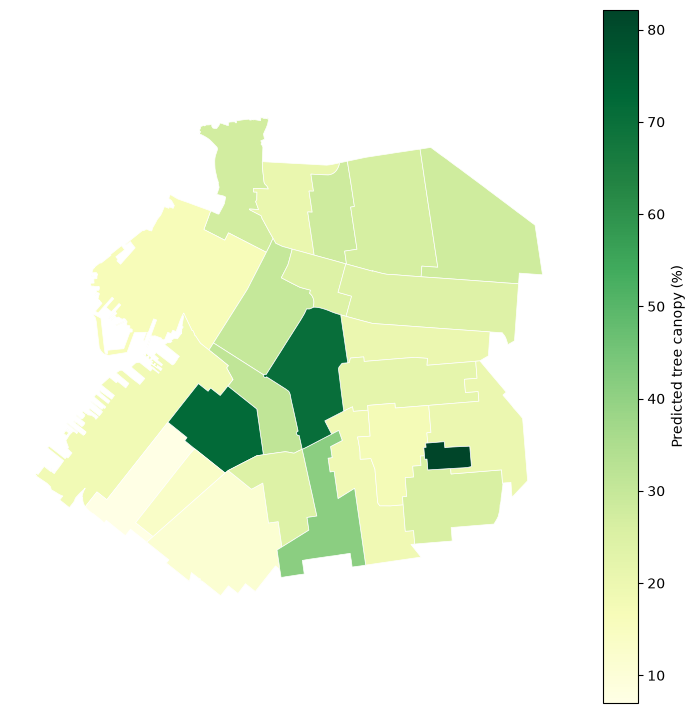

In [16]:
fig, ax = plt.subplots(figsize=(9, 9))
nta_web.plot(column="canopy_pred", cmap="YlGn", legend=True,
             edgecolor="white", linewidth=0.5, ax=ax,
             legend_kwds={"label": "Predicted tree canopy (%)"})
ax.set_axis_off()

plt.savefig(config.FIGURES / "05_choropleth.png", dpi=120, bbox_inches="tight")
plt.show()